<div style="background:#0f172a; color:white; padding:28px 32px; border-radius:12px; font-family:Arial, sans-serif; border:1px solid #1e293b;">
  <h2 style="margin:8px 0 0 0; font-size:22px; font-weight:500; color:#dbeafe;">GLM, Poisson Regression and Negative Binomial Regression</h2>
  <p style="margin:16px 0 0 0; font-size:15px; line-height:1.55; color:#e5e7eb; max-width:980px;">
    This notebook covers the Expert part of the MVD assignment. We use the Bike Sharing count target <b>cnt</b>, compare standard Linear Regression with Poisson Regression, check residual normality with a QQ plot, and implement Negative Binomial Regression with statsmodels.
  </p>
  <p style="margin:12px 0 0 0; font-size:14px; color:#bfdbfe;">
    <b>Ruturaj Mokashi</b> 
  </p>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">0. How to Use This Notebook</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p><b>Workflow:</b> read the blue explanation, run the short code cell, then read the green conclusion generated from the actual output.</p>
    <p><b>Important:</b> count prediction is different from normal numeric prediction. Bike rentals are counts, so the target cannot be negative. This is why we compare normal Linear Regression with count-aware models such as Poisson and Negative Binomial.</p>
    <p><b>Dataset note:</b> place the Kaggle Bike Sharing file as <code>data/hour.csv</code> or <code>data/day.csv</code>. If the file is not present, the notebook creates a deterministic Bike-Sharing-like fallback dataset so the notebook remains executable and reviewable.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">1. Controlling Coverage Matrix</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This table is the control checklist for Notebook 3. The MVD tasks are mandatory. The additional topics make the notebook professionally useful for real count-data modeling.</p>
    <table style="border-collapse:collapse; width:100%; font-size:14px;">
      <tr style="background:#dbeafe;">
        <th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Requirement</th>
        <th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Notebook Coverage</th>
        <th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Status</th>
      </tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Load Bike Sharing dataset</td><td style="border:1px solid #dbeafe; padding:8px;">Safe local loader with deterministic fallback</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Target variable: cnt</td><td style="border:1px solid #dbeafe; padding:8px;">Explicit target and leakage guard</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Train standard Linear Regression</td><td style="border:1px solid #dbeafe; padding:8px;">Baseline model section</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Check residuals for normality</td><td style="border:1px solid #dbeafe; padding:8px;">Residual summary and QQ plot</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Train PoissonRegressor</td><td style="border:1px solid #dbeafe; padding:8px;">sklearn Poisson model section</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Compare MAE and Mean Poisson Deviance</td><td style="border:1px solid #dbeafe; padding:8px;">Model comparison table and chart</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Implement Negative Binomial Regression</td><td style="border:1px solid #dbeafe; padding:8px;">statsmodels GLM Negative Binomial</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Explain when Negative Binomial is better</td><td style="border:1px solid #dbeafe; padding:8px;">Overdispersion ratio and final recommendation</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Additional professional topics</td><td style="border:1px solid #dbeafe; padding:8px;">Leakage warning, log link, pseudo-R², AIC/BIC, business interpretation</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
    </table>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">2. Core Idea — Why Count Models Are Needed</h3>
    <p><b>Simple idea:</b> Linear Regression predicts a number on a straight-line scale. That works well for many continuous targets, but bike rentals are counts. Counts have special rules: they cannot be negative, and their error pattern often grows as the count grows.</p>
    <p><b>Poisson Regression</b> is designed for count data. It predicts the log of the expected count, then converts it back into a positive count. This avoids impossible negative predictions.</p>
    <p><b>Negative Binomial Regression</b> is useful when counts are more spread out than Poisson expects. This situation is called <b>overdispersion</b>.</p>
    <table style="border-collapse:collapse; width:100%; font-size:14px;">
      <tr style="background:#dbeafe;"><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Model</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Plain-English Meaning</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Best Use Case</th></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>Linear Regression</b></td><td style="border:1px solid #dbeafe; padding:8px;">Predicts a continuous number directly.</td><td style="border:1px solid #dbeafe; padding:8px;">Simple baseline and residual diagnostics.</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>Poisson Regression</b></td><td style="border:1px solid #dbeafe; padding:8px;">Predicts non-negative counts.</td><td style="border:1px solid #dbeafe; padding:8px;">Count target where mean and variance are roughly similar.</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>Negative Binomial</b></td><td style="border:1px solid #dbeafe; padding:8px;">Poisson-like model with extra room for noisy counts.</td><td style="border:1px solid #dbeafe; padding:8px;">Count target with overdispersion.</td></tr>
    </table>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">3. Project Setup and Display Helpers</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This cell creates relative folders and small HTML display helpers. These helpers keep the notebook clean, print-ready and consistent with the approved V3 style.</p>
    <p><b>Variable flow:</b> <code>PROJECT_DIR</code> points to the current notebook folder. <code>DATA_DIR</code> is where Bike Sharing CSV files can be placed. <code>OUTPUT_DIR</code> stores optional output files.</p>
  </div>
</div>

In [1]:
# ============================================================
# CELL 1 — PROJECT SETUP AND PRINT-READY DISPLAY HELPERS
# ============================================================

# pathlib helps us create clean relative paths without showing personal folders.
from pathlib import Path

# HTML and display let us print clean formatted messages inside the notebook.
from IPython.display import HTML, display

# PROJECT_DIR is the folder where this notebook is currently running.
PROJECT_DIR = Path.cwd()

# DATA_DIR is where optional local files such as hour.csv or day.csv can be placed.
DATA_DIR = PROJECT_DIR / "data"

# OUTPUT_DIR is where generated outputs can be stored if needed.
OUTPUT_DIR = PROJECT_DIR / "outputs"

# Create folders if they do not already exist.
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# This helper shows green conclusion boxes after each code cell.
def show_conclusion(title, body):
    """Display a print-ready green conclusion box."""
    display(HTML(f"""
    <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:14px 18px; border-radius:8px; font-family:Arial, sans-serif; margin:14px 0; line-height:1.60;">
      <h4 style="margin:0 0 8px 0; color:#166534; font-size:18px;">{title}</h4>
      <div style="color:#14532d; font-size:14.5px;">{body}</div>
    </div>
    """))

# This helper shows blue information boxes when a note is useful.
def show_info(title, body):
    """Display a print-ready blue information box."""
    display(HTML(f"""
    <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:14px 18px; border-radius:8px; font-family:Arial, sans-serif; margin:14px 0; line-height:1.60;">
      <h4 style="margin:0 0 8px 0; color:#1e3a8a; font-size:18px;">{title}</h4>
      <div style="color:#1e3a8a; font-size:14.5px;">{body}</div>
    </div>
    """))

# Confirm setup.
show_conclusion(
    "Setup complete",
    f"The notebook is running from <code>{PROJECT_DIR.name}</code>. The relative data folder is <code>{DATA_DIR.name}/</code> and the output folder is <code>{OUTPUT_DIR.name}/</code>. No personal path is exposed."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">4. Import Libraries</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This cell imports the tools needed for data handling, preprocessing, regression models, count-model evaluation, diagnostic plots and statsmodels GLM fitting.</p>
    <p><b>Important:</b> there is no package installation inside this notebook. That keeps the kernel stable and avoids the kernel-killing issue.</p>
  </div>
</div>

In [2]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

# Core table and numeric libraries.
import pandas as pd
import numpy as np

# Matplotlib is used for clean, print-ready charts.
import matplotlib.pyplot as plt

# scipy provides the QQ plot calculation.
from scipy import stats

# Warnings are filtered to keep notebook output readable.
import warnings
warnings.filterwarnings("ignore")

# sklearn tools for preprocessing and model evaluation.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_poisson_deviance, r2_score

# statsmodels is used for GLM Poisson and Negative Binomial.
import statsmodels.api as sm

# Pandas display settings make tables easier to read.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# Confirm imports.
show_conclusion(
    "Libraries imported",
    "All required tools are available: pandas, numpy, matplotlib, scipy, sklearn Linear/Poisson regression, evaluation metrics, and statsmodels GLM families."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">5. Load the Bike Sharing Dataset Safely</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The MVD uses the Bike Sharing dataset and target <code>cnt</code>. This loader searches for common Kaggle file names such as <code>hour.csv</code> and <code>day.csv</code> inside the relative <code>data/</code> folder.</p>
    <p>If no file is found, the cell creates a deterministic fallback dataset with the same main structure. That means the notebook can be executed, checked and printed even before the Kaggle file is added locally.</p>
  </div>
</div>

In [3]:
# ============================================================
# CELL 3 — SAFE DATA LOADING WITH DETERMINISTIC FALLBACK
# ============================================================

# These are common locations and file names for the Bike Sharing Kaggle/UCI files.
candidate_files = [
    DATA_DIR / "hour.csv",
    DATA_DIR / "day.csv",
    DATA_DIR / "bike_sharing.csv",
    DATA_DIR / "bike_sharing_hour.csv",
    DATA_DIR / "Bike-Sharing-Dataset" / "hour.csv",
    DATA_DIR / "Bike-Sharing-Dataset" / "day.csv",
]

# Try to load the first available CSV file that contains the target column cnt.
bike_df = None
data_source = None

for file_path in candidate_files:
    if file_path.exists():
        possible_df = pd.read_csv(file_path)
        if "cnt" in possible_df.columns:
            bike_df = possible_df.copy()
            data_source = f"local file: {file_path.name}"
            break

# If no real file exists, create a deterministic fallback dataset.
if bike_df is None:
    rng = np.random.default_rng(42)
    n_rows = 900
    dates = pd.date_range("2011-01-01", periods=n_rows, freq="H")
    hour = dates.hour
    month = dates.month
    weekday = dates.weekday
    season = np.select([month.isin([12, 1, 2]), month.isin([3, 4, 5]), month.isin([6, 7, 8])], [1, 2, 3], default=4)
    workingday = ((weekday < 5)).astype(int)
    holiday = (rng.random(n_rows) < 0.03).astype(int)
    weather = rng.choice([1, 2, 3], size=n_rows, p=[0.60, 0.30, 0.10])
    temp = np.clip(0.45 + 0.25 * np.sin(2 * np.pi * (month - 3) / 12) + rng.normal(0, 0.08, n_rows), 0.05, 0.95)
    hum = np.clip(0.60 - 0.18 * np.sin(2 * np.pi * (month - 3) / 12) + rng.normal(0, 0.10, n_rows), 0.15, 1.00)
    windspeed = np.clip(rng.normal(0.20, 0.07, n_rows), 0.02, 0.60)
    commute_peak = ((hour.isin([7, 8, 17, 18])) & (workingday == 1)).astype(int)
    leisure_peak = ((hour.isin([11, 12, 13, 14, 15, 16])) & (workingday == 0)).astype(int)
    expected_count = np.exp(3.2 + 1.15 * temp - 0.75 * hum - 0.65 * (weather == 3) + 0.75 * commute_peak + 0.45 * leisure_peak)
    cnt = rng.negative_binomial(n=8, p=8 / (8 + expected_count)).astype(int)
    registered = np.round(cnt * rng.uniform(0.65, 0.90, n_rows)).astype(int)
    casual = np.maximum(cnt - registered, 0)
    bike_df = pd.DataFrame({
        "instant": np.arange(1, n_rows + 1),
        "dteday": dates.date.astype(str),
        "season": season.astype(int),
        "yr": (dates.year - dates.year.min()).astype(int),
        "mnth": month.astype(int),
        "hr": hour.astype(int),
        "holiday": holiday.astype(int),
        "weekday": weekday.astype(int),
        "workingday": workingday.astype(int),
        "weathersit": weather.astype(int),
        "temp": temp,
        "atemp": np.clip(temp + rng.normal(0, 0.03, n_rows), 0.05, 0.95),
        "hum": hum,
        "windspeed": windspeed,
        "casual": casual,
        "registered": registered,
        "cnt": cnt,
    })
    data_source = "deterministic fallback dataset"

# Display a small preview.
display(bike_df.head())

# Output-aware conclusion.
show_conclusion(
    "Dataset loaded",
    f"Source used: <b>{data_source}</b>. The working dataframe is <code>bike_df</code> with <b>{bike_df.shape[0]:,}</b> rows and <b>{bike_df.shape[1]}</b> columns. The target column <code>cnt</code> is available."
)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,5,0,1,0.414905,0.411371,0.660831,0.228683,5,11,16
1,2,2011-01-01,1,0,1,1,0,5,0,1,0.151036,0.242978,0.737891,0.240684,5,11,16
2,3,2011-01-01,1,0,1,2,0,5,0,1,0.239127,0.198753,0.800866,0.142156,4,11,15
3,4,2011-01-01,1,0,1,3,0,5,0,1,0.139398,0.135645,0.655054,0.250241,4,12,16
4,5,2011-01-01,1,0,1,4,0,5,0,3,0.171285,0.128573,0.685876,0.207936,2,12,14


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">6. Inspect Columns, Missing Values and Target</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Before modeling, we confirm the dataset structure. For Bike Sharing, <code>cnt</code> is the total rental count. Two columns, <code>casual</code> and <code>registered</code>, are dangerous leakage columns because <code>cnt = casual + registered</code>.</p>
    <p><b>Variable flow:</b> this cell creates summary tables that guide the modeling feature selection in the next step.</p>
  </div>
</div>

In [4]:
# ============================================================
# CELL 4 — BASIC DATASET INSPECTION
# ============================================================

# Count missing values in each column.
missing_summary = (
    bike_df.isna().sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_values"})
)

# Keep only columns with missing values for a cleaner display.
missing_nonzero = missing_summary.query("missing_values > 0")

# Summarize the count target.
target_summary = bike_df["cnt"].describe().round(2).to_frame("cnt_summary")

# Display shape, columns and target summary.
print("Shape:", bike_df.shape)
print("Columns:", list(bike_df.columns))
display(target_summary)

# Display missing values only if they exist.
if missing_nonzero.empty:
    print("No missing values found.")
else:
    display(missing_nonzero)

# Output-aware conclusion.
missing_count = int(bike_df.isna().sum().sum())
show_conclusion(
    "Dataset inspection complete",
    f"The dataset has <b>{bike_df.shape[0]:,}</b> rows. Total missing values found: <b>{missing_count:,}</b>. The target <code>cnt</code> ranges from <b>{bike_df['cnt'].min():,.0f}</b> to <b>{bike_df['cnt'].max():,.0f}</b>, which confirms this is a count-prediction problem."
)

Shape: (900, 17)
Columns: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,cnt_summary
count,900.00
mean,21.18
std,12.12
min,3.00
25%,13.00
50%,18.00
75%,27.00
max,86.00


No missing values found.


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">7. Check Count Behaviour and Overdispersion</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Poisson Regression assumes that the count target has variance roughly similar to its mean. In real business data, counts are often more spread out. That is called <b>overdispersion</b>.</p>
    <p><b>Why this matters:</b> if variance is much larger than mean, Negative Binomial is often a better candidate than Poisson because it allows extra variability.</p>
  </div>
</div>

In [5]:
# ============================================================
# CELL 5 — COUNT TARGET MEAN, VARIANCE AND OVERDISPERSION
# ============================================================

# Calculate target mean and variance.
cnt_mean = bike_df["cnt"].mean()
cnt_variance = bike_df["cnt"].var()

# Overdispersion ratio compares variance against mean.
overdispersion_ratio = cnt_variance / cnt_mean if cnt_mean > 0 else np.nan

# Create a compact table for printing.
overdispersion_table = pd.DataFrame({
    "Metric": ["Mean of cnt", "Variance of cnt", "Variance / Mean"],
    "Value": [cnt_mean, cnt_variance, overdispersion_ratio]
})
overdispersion_table["Value"] = overdispersion_table["Value"].round(3)

display(overdispersion_table)

# Create an output-aware interpretation.
if overdispersion_ratio > 2:
    dispersion_message = "The variance is much larger than the mean. This suggests overdispersion, so Negative Binomial is likely worth testing."
elif overdispersion_ratio > 1.2:
    dispersion_message = "The variance is moderately larger than the mean. Poisson may still be useful, but Negative Binomial should be checked."
else:
    dispersion_message = "The variance is close to the mean. This is more compatible with the basic Poisson assumption."

show_conclusion(
    "Count behaviour checked",
    f"The count target has mean <b>{cnt_mean:,.2f}</b> and variance <b>{cnt_variance:,.2f}</b>. The variance/mean ratio is <b>{overdispersion_ratio:,.2f}</b>. {dispersion_message}"
)

,Metric,Value
0,Mean of cnt,21.176
1,Variance of cnt,146.908
2,Variance / Mean,6.938


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">8. Build Safe Feature Set and Prevent Leakage</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This is a very important modeling step. We must not use <code>casual</code> or <code>registered</code> to predict <code>cnt</code>, because the target is the sum of those two columns. Using them would be data leakage and would make the model look unrealistically good.</p>
    <p><b>Variable flow:</b> this cell creates <code>feature_columns</code>, <code>numeric_features</code>, <code>categorical_features</code>, <code>X</code> and <code>y</code>. These objects are used for splitting, preprocessing and model training.</p>
  </div>
</div>

In [6]:
# ============================================================
# CELL 6 — FEATURE SELECTION WITH LEAKAGE GUARD
# ============================================================

# Define the target column required by the MVD.
target_column = "cnt"

# Leakage columns are not allowed as model inputs.
leakage_columns = ["cnt", "casual", "registered"]

# Identifier/date columns are also not direct model inputs.
id_date_columns = ["instant", "dteday"]

# Preferred Bike Sharing feature columns used when available.
preferred_features = [
    "season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit",
    "temp", "atemp", "hum", "windspeed"
]

# Keep preferred features that exist in the current dataframe.
feature_columns = [col for col in preferred_features if col in bike_df.columns]

# If a different Bike Sharing file has fewer columns, fall back to safe numeric columns.
if len(feature_columns) < 3:
    blocked = set(leakage_columns + id_date_columns)
    feature_columns = [col for col in bike_df.columns if col not in blocked and pd.api.types.is_numeric_dtype(bike_df[col])]

# Separate numeric and categorical-style columns.
categorical_features = [col for col in feature_columns if col in ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"]]
numeric_features = [col for col in feature_columns if col not in categorical_features]

# Create model input matrix X and target vector y.
X = bike_df[feature_columns].copy()
y = bike_df[target_column].copy()

# Display selected feature groups.
print("Target column:", target_column)
print("Feature columns:", feature_columns)
print("Numeric features:", numeric_features)
print("Categorical-style features:", categorical_features)
print("Blocked leakage columns:", leakage_columns)

# Output-aware conclusion.
show_conclusion(
    "Feature set created safely",
    f"The model will use <b>{len(feature_columns)}</b> features. Leakage columns <code>casual</code> and <code>registered</code> are blocked. This keeps the prediction task realistic because the model must learn from conditions, not from target components."
)

Target column: cnt
Feature columns: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
Numeric features: ['temp', 'atemp', 'hum', 'windspeed']
Categorical-style features: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
Blocked leakage columns: ['cnt', 'casual', 'registered']


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">9. Use a Time-Aware Train/Test Split</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Bike Sharing data has a time order. A random split can mix future periods into training and make the model look too good. Here we use a simple chronological split: earlier rows train the model, later rows test it.</p>
    <p><b>Variable flow:</b> <code>X_train_raw</code> and <code>y_train</code> train the models. <code>X_test_raw</code> and <code>y_test</code> evaluate whether the models work on later unseen data.</p>
  </div>
</div>

In [7]:
# ============================================================
# CELL 7 — TIME-AWARE TRAIN/TEST SPLIT
# ============================================================

# If date/hour columns exist, sort before splitting.
sort_columns = [col for col in ["dteday", "hr", "instant"] if col in bike_df.columns]

# Create a sorted copy for time-aware modeling.
sorted_df = bike_df.sort_values(sort_columns).reset_index(drop=True) if sort_columns else bike_df.reset_index(drop=True)

# Recreate X and y from the sorted dataframe.
X_sorted = sorted_df[feature_columns].copy()
y_sorted = sorted_df[target_column].copy()

# Use the first 75% for training and the last 25% for testing.
split_index = int(len(sorted_df) * 0.75)

# Raw feature splits are not yet encoded/scaled.
X_train_raw = X_sorted.iloc[:split_index].copy()
X_test_raw = X_sorted.iloc[split_index:].copy()

# Target splits use the same row positions.
y_train = y_sorted.iloc[:split_index].copy()
y_test = y_sorted.iloc[split_index:].copy()

# Display split sizes.
split_table = pd.DataFrame({
    "Split": ["Training", "Testing"],
    "Rows": [len(X_train_raw), len(X_test_raw)],
    "Target Mean": [y_train.mean(), y_test.mean()]
}).round(2)

display(split_table)

# Output-aware conclusion.
show_conclusion(
    "Train/test split complete",
    f"The model will train on <b>{len(X_train_raw):,}</b> earlier rows and test on <b>{len(X_test_raw):,}</b> later rows. This is more realistic for time-related Bike Sharing data than a random split."
)

,Split,Rows,Target Mean
0,Training,675,20.20
1,Testing,225,24.12


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">10. Preprocess Features Without Data Leakage</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>We fit preprocessing only on the training data. Numeric features are scaled. Categorical-style features such as season, month, hour and weather are one-hot encoded. We drop the first dummy level so the statsmodels GLM matrix stays stable and avoids duplicated dummy information.</p>
    <p><b>Leakage rule:</b> the test set must only be transformed using rules learned from training. We do not fit preprocessing on the full dataset.</p>
  </div>
</div>

In [8]:
# ============================================================
# CELL 8 — PREPROCESSING: SCALE NUMERIC, ONE-HOT ENCODE CATEGORICAL
# ============================================================

# Create OneHotEncoder in a way that supports both newer and older sklearn versions.
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False, drop="first")

# The ColumnTransformer applies the correct preprocessing to each feature group.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", one_hot_encoder, categorical_features),
    ],
    remainder="drop"
)

# Fit preprocessing only on training data, then transform train and test.
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

# Get processed feature names for interpretation and statsmodels tables.
processed_feature_names = preprocessor.get_feature_names_out()

# Display processed shapes.
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)
print("Number of processed features:", len(processed_feature_names))

# Output-aware conclusion.
show_conclusion(
    "Preprocessing complete",
    f"The raw feature table has <b>{len(feature_columns)}</b> selected columns. After scaling and one-hot encoding, the model uses <b>{X_train_processed.shape[1]}</b> processed features. Preprocessing was fitted only on training data, preventing leakage."
)

X_train_processed shape: (675, 37)
X_test_processed shape: (225, 37)
Number of processed features: 37


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">11. Build a Simple Mean Baseline</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>A baseline model is a simple reference point. Here the baseline predicts the average training count for every test row. Any serious model should beat this baseline.</p>
    <p><b>Variable flow:</b> <code>baseline_pred</code> becomes the simple benchmark used later in the model comparison table.</p>
  </div>
</div>

In [9]:
# ============================================================
# CELL 9 — MEAN BASELINE MODEL
# ============================================================

# The baseline prediction is the average training count repeated for every test row.
baseline_value = y_train.mean()
baseline_pred = np.repeat(baseline_value, len(y_test))

# Calculate simple baseline metrics.
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

# Store results in a dictionary for later comparison.
model_results = {
    "Mean Baseline": {
        "MAE": baseline_mae,
        "RMSE": baseline_rmse,
        "R2": baseline_r2,
        "Mean Poisson Deviance": mean_poisson_deviance(y_test, np.maximum(baseline_pred, 1e-6)),
    }
}

# Display baseline metrics.
baseline_table = pd.DataFrame(model_results).T.round(3)
display(baseline_table)

# Output-aware conclusion.
show_conclusion(
    "Baseline created",
    f"The mean baseline predicts <b>{baseline_value:,.2f}</b> rentals for every test row. Its MAE is <b>{baseline_mae:,.2f}</b>. The next models must improve on this simple benchmark."
)

,MAE,RMSE,R2,Mean Poisson Deviance
Mean Baseline,9.653,13.526,-0.092,7.005


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">12. Train Standard Linear Regression</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The MVD first asks us to train a standard Linear Regression model on the Bike Sharing target <code>cnt</code>. This is our normal regression baseline before moving to GLM models.</p>
    <p><b>Important limitation:</b> Linear Regression can predict negative counts because it does not know that rentals must be non-negative. This is one reason count models may be better.</p>
  </div>
</div>

In [10]:
# ============================================================
# CELL 10 — STANDARD LINEAR REGRESSION MODEL
# ============================================================

# Create the standard Linear Regression model.
linear_model = LinearRegression()

# Train the model on processed training features and count target.
linear_model.fit(X_train_processed, y_train)

# Predict counts on the processed test features.
linear_pred = linear_model.predict(X_test_processed)

# For Poisson deviance only, predictions must be positive.
linear_pred_positive = np.maximum(linear_pred, 1e-6)

# Calculate evaluation metrics.
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)
linear_mpd = mean_poisson_deviance(y_test, linear_pred_positive)

# Store results for final comparison.
model_results["Linear Regression"] = {
    "MAE": linear_mae,
    "RMSE": linear_rmse,
    "R2": linear_r2,
    "Mean Poisson Deviance": linear_mpd,
}

# Count negative predictions, because that is a practical weakness for count targets.
negative_prediction_count = int((linear_pred < 0).sum())

# Display metrics.
linear_table = pd.DataFrame(model_results).T.round(3)
display(linear_table)

# Output-aware conclusion.
show_conclusion(
    "Linear Regression trained",
    f"Linear Regression achieved MAE <b>{linear_mae:,.2f}</b>, RMSE <b>{linear_rmse:,.2f}</b> and R² <b>{linear_r2:,.3f}</b>. It produced <b>{negative_prediction_count}</b> negative predictions, which shows why normal regression is not always ideal for count data."
)

,MAE,RMSE,R2,Mean Poisson Deviance
Mean Baseline,9.653,13.526,-0.092,7.005
Linear Regression,8.194,10.871,0.295,4.345


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">13. Check Linear Regression Residuals</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Residuals are the differences between actual and predicted values. If Linear Regression assumptions work well, residuals should look roughly centered around zero and should not show extreme skew.</p>
    <p><b>Variable flow:</b> <code>linear_residuals</code> will be used for the residual summary, residual plot and QQ plot.</p>
  </div>
</div>

In [11]:
# ============================================================
# CELL 11 — LINEAR REGRESSION RESIDUAL SUMMARY
# ============================================================

# Residual = actual count minus predicted count.
linear_residuals = y_test.values - linear_pred

# Create a compact residual summary table.
residual_summary = pd.Series(linear_residuals, name="linear_residuals").describe().round(3).to_frame()

display(residual_summary)

# Calculate skewness to understand residual shape.
residual_skew = pd.Series(linear_residuals).skew()

# Interpret the residual center.
residual_mean = linear_residuals.mean()

# Output-aware conclusion.
show_conclusion(
    "Residuals calculated",
    f"The average residual is <b>{residual_mean:,.2f}</b>. Residual skewness is <b>{residual_skew:,.2f}</b>. Large skewness or very wide residual spread suggests that normal Linear Regression may not fully fit the count-data pattern."
)

,linear_residuals
count,225.000
mean,1.003
std,10.849
min,-25.072
25%,-6.911
50%,-0.115
75%,6.750
max,47.223


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">14. Residual Plot for Linear Regression</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>A residual plot shows whether the model makes systematic errors. A good residual plot should look like random noise around zero. Patterns suggest that the model is missing structure.</p>
    <p><b>Business meaning:</b> if the model underpredicts during high-demand periods, the business may underestimate staffing, inventory or bike availability needs.</p>
  </div>
</div>

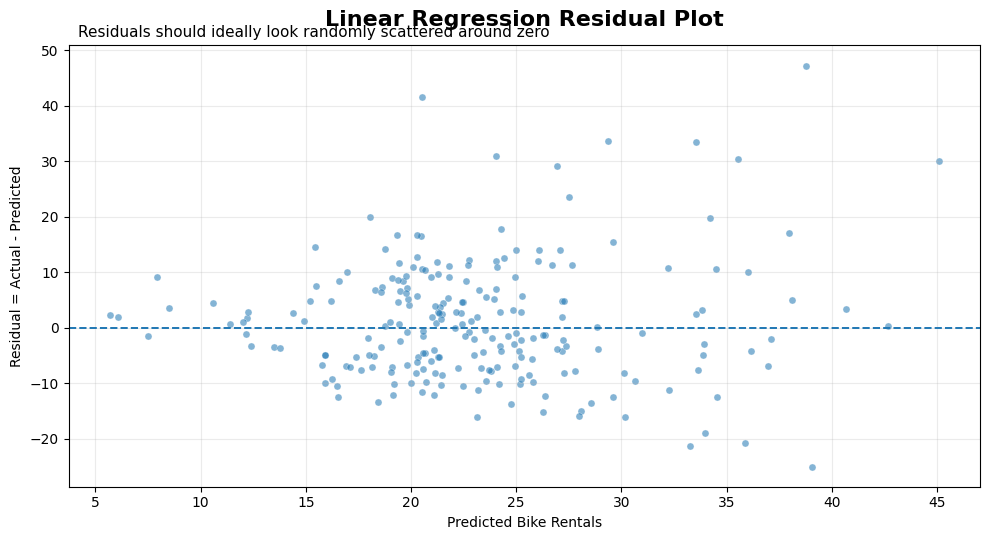

In [12]:
# ============================================================
# CELL 12 — RESIDUAL PLOT
# ============================================================

# Create a print-ready residual plot.
fig, ax = plt.subplots(figsize=(10, 5.5))

# Scatter predicted values against residuals.
ax.scatter(linear_pred, linear_residuals, alpha=0.55, s=26, edgecolor="white", linewidth=0.4)

# Add a horizontal zero-error line.
ax.axhline(0, linestyle="--", linewidth=1.4)

# Add chart titles and labels.
ax.set_title("Linear Regression Residual Plot", fontsize=16, fontweight="bold", pad=14)
ax.text(0.01, 1.02, "Residuals should ideally look randomly scattered around zero", transform=ax.transAxes, fontsize=11)
ax.set_xlabel("Predicted Bike Rentals")
ax.set_ylabel("Residual = Actual - Predicted")

# Light grid for readability.
ax.grid(axis="both", alpha=0.25)
plt.tight_layout()
plt.show()

# Output-aware conclusion.
show_conclusion(
    "Residual plot created",
    "Use this chart to check whether errors are random or patterned. A visible curve, funnel shape, or uneven spread suggests that Linear Regression is struggling with the count-data structure."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">15. QQ Plot for Residual Normality</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The MVD specifically asks us to check residuals for normality using a QQ plot. A QQ plot compares model residuals with a normal distribution. If the points follow the diagonal line, residuals are roughly normal.</p>
    <p><b>Why it matters:</b> count data often produces non-normal residuals. This gives us evidence for trying Poisson and Negative Binomial models.</p>
  </div>
</div>

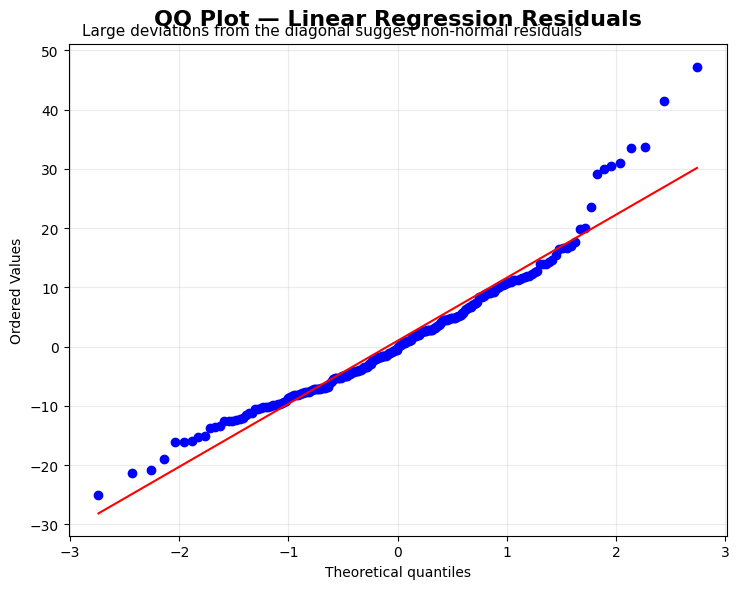

In [13]:
# ============================================================
# CELL 13 — QQ PLOT FOR RESIDUAL NORMALITY
# ============================================================

# Create a QQ plot using scipy.
fig, ax = plt.subplots(figsize=(7.5, 6))
stats.probplot(linear_residuals, dist="norm", plot=ax)

# Improve chart readability.
ax.set_title("QQ Plot — Linear Regression Residuals", fontsize=16, fontweight="bold", pad=14)
ax.text(0.02, 1.02, "Large deviations from the diagonal suggest non-normal residuals", transform=ax.transAxes, fontsize=11)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Output-aware conclusion.
show_conclusion(
    "QQ plot created",
    "If the residual points bend away from the diagonal line, the normal-error assumption is weak. This is common for count targets like bike rentals and supports testing GLM count models."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">16. Train Poisson Regression with sklearn</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Poisson Regression is designed for count targets. It uses a log link internally, which keeps predictions positive. This is more natural for counts than normal Linear Regression.</p>
    <p><b>Variable flow:</b> <code>poisson_model</code> learns from <code>X_train_processed</code> and <code>y_train</code>. <code>poisson_pred</code> is evaluated on the same test set as Linear Regression.</p>
  </div>
</div>

In [14]:
# ============================================================
# CELL 14 — SKLEARN POISSON REGRESSION
# ============================================================

# Create the PoissonRegressor model.
# The newton-cholesky solver is fast and stable for this tabular count model.
try:
    poisson_model = PoissonRegressor(alpha=1.0, max_iter=100, solver="newton-cholesky")
except TypeError:
    poisson_model = PoissonRegressor(alpha=1.0, max_iter=300)

# Train the Poisson model on processed training data.
poisson_model.fit(X_train_processed, y_train)

# Predict counts on the test set.
poisson_pred = poisson_model.predict(X_test_processed)

# Calculate Poisson model metrics.
poisson_mae = mean_absolute_error(y_test, poisson_pred)
poisson_rmse = np.sqrt(mean_squared_error(y_test, poisson_pred))
poisson_r2 = r2_score(y_test, poisson_pred)
poisson_mpd = mean_poisson_deviance(y_test, np.maximum(poisson_pred, 1e-6))

# Store results for final comparison.
model_results["PoissonRegressor"] = {
    "MAE": poisson_mae,
    "RMSE": poisson_rmse,
    "R2": poisson_r2,
    "Mean Poisson Deviance": poisson_mpd,
}

# Display current comparison.
current_comparison = pd.DataFrame(model_results).T.round(3)
display(current_comparison)

# Output-aware conclusion.
show_conclusion(
    "PoissonRegressor trained",
    f"PoissonRegressor achieved MAE <b>{poisson_mae:,.2f}</b> and Mean Poisson Deviance <b>{poisson_mpd:,.3f}</b>. Unlike Linear Regression, its predictions are naturally positive because it is a count model."
)

,MAE,RMSE,R2,Mean Poisson Deviance
Mean Baseline,9.653,13.526,-0.092,7.005
Linear Regression,8.194,10.871,0.295,4.345
PoissonRegressor,8.279,11.116,0.263,4.541


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">17. Compare Linear Regression and Poisson Regression</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The MVD asks us to compare MAE and Mean Poisson Deviance. MAE is easy to explain to business users because it means average absolute rental-count error. Mean Poisson Deviance is count-model-specific and rewards count predictions that fit Poisson-like behaviour.</p>
    <p><b>Rule of thumb:</b> lower MAE is better, lower RMSE is better, lower Mean Poisson Deviance is better, and higher R² is better.</p>
  </div>
</div>

In [15]:
# ============================================================
# CELL 15 — COMPARISON TABLE FOR BASELINE, LINEAR AND POISSON
# ============================================================

# Convert the stored model results into a table.
comparison_table = pd.DataFrame(model_results).T

# Sort by MAE because MAE is a clear business metric.
comparison_table = comparison_table.sort_values("MAE")

# Display rounded metrics.
display(comparison_table.round(3))

# Identify the current best model by MAE.
best_model_by_mae = comparison_table["MAE"].idxmin()
best_mae = comparison_table.loc[best_model_by_mae, "MAE"]

# Output-aware conclusion.
show_conclusion(
    "Initial model comparison complete",
    f"Based on MAE, the best model so far is <b>{best_model_by_mae}</b> with MAE <b>{best_mae:,.2f}</b>. We still need to test Negative Binomial because the overdispersion check may justify it."
)

,MAE,RMSE,R2,Mean Poisson Deviance
Linear Regression,8.194,10.871,0.295,4.345
PoissonRegressor,8.279,11.116,0.263,4.541
Mean Baseline,9.653,13.526,-0.092,7.005


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">18. Fit statsmodels Poisson GLM for Inference Metrics</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>sklearn is prediction-focused. statsmodels is stronger for statistical model diagnostics such as AIC, BIC and deviance. We fit a statsmodels Poisson GLM to support model comparison and professional interpretation.</p>
    <p><b>Variable flow:</b> <code>X_train_sm</code> and <code>X_test_sm</code> are statsmodels-ready matrices with an intercept column added.</p>
  </div>
</div>

In [16]:
# ============================================================
# CELL 16 — STATSMODELS POISSON GLM
# ============================================================

# Convert processed sklearn arrays into statsmodels matrices with an intercept.
X_train_sm = sm.add_constant(X_train_processed, has_constant="add")
X_test_sm = sm.add_constant(X_test_processed, has_constant="add")

# Fit a Poisson GLM with log link using statsmodels.
poisson_glm = sm.GLM(y_train.values, X_train_sm, family=sm.families.Poisson()).fit(maxiter=100, disp=0)

# Predict on the test set.
poisson_glm_pred = poisson_glm.predict(X_test_sm)

# Calculate statsmodels Poisson metrics.
poisson_glm_mae = mean_absolute_error(y_test, poisson_glm_pred)
poisson_glm_mpd = mean_poisson_deviance(y_test, np.maximum(poisson_glm_pred, 1e-6))

# Create a compact diagnostic table.
poisson_glm_table = pd.DataFrame({
    "Metric": ["AIC", "BIC (deviance-based)", "Training Deviance", "Test MAE", "Test Mean Poisson Deviance"],
    "Value": [poisson_glm.aic, poisson_glm.bic_deviance, poisson_glm.deviance, poisson_glm_mae, poisson_glm_mpd]
}).round(3)

display(poisson_glm_table)

# Output-aware conclusion.
show_conclusion(
    "statsmodels Poisson GLM fitted",
    f"The Poisson GLM has AIC <b>{poisson_glm.aic:,.2f}</b> and test MAE <b>{poisson_glm_mae:,.2f}</b>. AIC/BIC are useful for comparing statsmodels GLM models fitted on the same target and feature design."
)

,Metric,Value
0,AIC,5977.870
1,BIC (deviance-based),-1425.480
2,Training Deviance,2730.907
3,Test MAE,8.128
4,Test Mean Poisson Deviance,4.162


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">19. Estimate Dispersion Strength for Negative Binomial</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Negative Binomial adds an extra dispersion parameter. In plain language, this gives the model more room when the count target is noisier than Poisson expects.</p>
    <p>This cell creates a practical starting value for the Negative Binomial dispersion strength using the training target mean and variance.</p>
  </div>
</div>

In [17]:
# ============================================================
# CELL 17 — PRACTICAL NEGATIVE BINOMIAL ALPHA ESTIMATE
# ============================================================

# Negative Binomial variance form: Var(Y) = mean + alpha * mean^2.
train_mean = y_train.mean()
train_variance = y_train.var()

# Estimate alpha from mean and variance, then keep it inside a stable range.
raw_alpha_estimate = (train_variance - train_mean) / (train_mean ** 2) if train_mean > 0 else 0.1
nb_alpha = float(np.clip(raw_alpha_estimate, 0.001, 2.0))

# Create a compact table.
nb_alpha_table = pd.DataFrame({
    "Metric": ["Training mean", "Training variance", "Raw alpha estimate", "Alpha used"],
    "Value": [train_mean, train_variance, raw_alpha_estimate, nb_alpha]
}).round(4)

display(nb_alpha_table)

# Output-aware conclusion.
show_conclusion(
    "Negative Binomial dispersion prepared",
    f"The estimated dispersion alpha used for the Negative Binomial GLM is <b>{nb_alpha:,.4f}</b>. A higher alpha means the model allows more extra variability beyond Poisson."
)

,Metric,Value
0,Training mean,20.1956
1,Training variance,136.1546
2,Raw alpha estimate,0.2843
3,Alpha used,0.2843


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">20. Fit Negative Binomial Regression with statsmodels</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The MVD asks us to implement Negative Binomial Regression with statsmodels. We use a GLM with Negative Binomial family and log link.</p>
    <p><b>When it helps:</b> if the count target is overdispersed, Negative Binomial can fit more realistic count variation than Poisson.</p>
  </div>
</div>

In [18]:
# ============================================================
# CELL 18 — STATSMODELS NEGATIVE BINOMIAL GLM
# ============================================================

# Fit a Negative Binomial GLM using statsmodels.
negative_binomial_glm = sm.GLM(
    y_train.values,
    X_train_sm,
    family=sm.families.NegativeBinomial(alpha=nb_alpha)
).fit(maxiter=100, disp=0)

# Predict test counts.
negative_binomial_pred = negative_binomial_glm.predict(X_test_sm)

# Calculate Negative Binomial metrics.
nb_mae = mean_absolute_error(y_test, negative_binomial_pred)
nb_rmse = np.sqrt(mean_squared_error(y_test, negative_binomial_pred))
nb_r2 = r2_score(y_test, negative_binomial_pred)
nb_mpd = mean_poisson_deviance(y_test, np.maximum(negative_binomial_pred, 1e-6))

# Store results for final model comparison.
model_results["Negative Binomial GLM"] = {
    "MAE": nb_mae,
    "RMSE": nb_rmse,
    "R2": nb_r2,
    "Mean Poisson Deviance": nb_mpd,
}

# Display a compact statsmodels comparison table.
nb_glm_table = pd.DataFrame({
    "Metric": ["AIC", "BIC (deviance-based)", "Training Deviance", "Test MAE", "Test Mean Poisson Deviance"],
    "Value": [negative_binomial_glm.aic, negative_binomial_glm.bic_deviance, negative_binomial_glm.deviance, nb_mae, nb_mpd]
}).round(3)

display(nb_glm_table)

# Output-aware conclusion.
show_conclusion(
    "Negative Binomial GLM trained",
    f"Negative Binomial achieved MAE <b>{nb_mae:,.2f}</b> and Mean Poisson Deviance <b>{nb_mpd:,.3f}</b>. Compare this with Poisson and Linear Regression to decide whether the extra dispersion handling helped."
)

,Metric,Value
0,AIC,4907.800
1,BIC (deviance-based),-3738.141
2,Training Deviance,418.246
3,Test MAE,8.198
4,Test Mean Poisson Deviance,4.207


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">21. Final Model Comparison Table</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This table compares all models using the same test set. It includes the required MVD metrics: MAE and Mean Poisson Deviance. It also includes RMSE and R² for additional context.</p>
    <p><b>Interpretation rule:</b> select the model based on the business metric first. For operational planning, MAE is easy to explain. For count-model quality, Mean Poisson Deviance is more statistically aligned.</p>
  </div>
</div>

In [19]:
# ============================================================
# CELL 19 — FINAL MODEL COMPARISON TABLE
# ============================================================

# Convert results to a sorted dataframe.
final_comparison = pd.DataFrame(model_results).T.sort_values("MAE")

# Add model rank based on MAE.
final_comparison.insert(0, "Rank by MAE", range(1, len(final_comparison) + 1))

# Display final rounded comparison.
display(final_comparison.round(3))

# Identify winners by MAE and Mean Poisson Deviance.
best_mae_model = final_comparison["MAE"].idxmin()
best_mpd_model = final_comparison["Mean Poisson Deviance"].idxmin()

# Output-aware conclusion.
show_conclusion(
    "Final comparison complete",
    f"The best model by MAE is <b>{best_mae_model}</b>. The best model by Mean Poisson Deviance is <b>{best_mpd_model}</b>. If these differ, explain the decision based on business use case: simple operational error versus count-model statistical fit."
)

,Rank by MAE,MAE,RMSE,R2,Mean Poisson Deviance
Linear Regression,1,8.194,10.871,0.295,4.345
Negative Binomial GLM,2,8.198,10.694,0.318,4.207
PoissonRegressor,3,8.279,11.116,0.263,4.541
Mean Baseline,4,9.653,13.526,-0.092,7.005


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">22. BI-Ready Model Comparison Chart</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This chart shows MAE by model. MAE is easy to explain: on average, how many rentals away was the prediction?</p>
    <p><b>Business meaning:</b> lower MAE means the model is more useful for planning bike supply, staff scheduling and demand management.</p>
  </div>
</div>

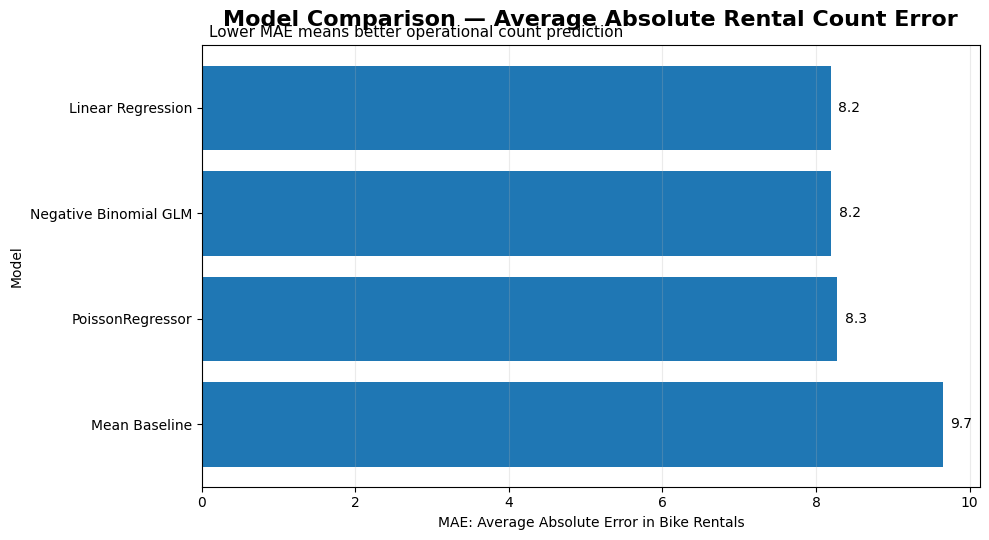

In [20]:
# ============================================================
# CELL 20 — BI-READY MAE COMPARISON CHART
# ============================================================

# Prepare chart data sorted from best to worst MAE.
chart_data = final_comparison.sort_values("MAE", ascending=True)

# Create a horizontal bar chart.
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(chart_data.index, chart_data["MAE"])

# Invert y-axis so the best model appears at the top.
ax.invert_yaxis()

# Add labels to each bar.
for bar in bars:
    width = bar.get_width()
    ax.text(width + chart_data["MAE"].max() * 0.01, bar.get_y() + bar.get_height()/2, f"{width:,.1f}", va="center", fontsize=10)

# Add titles and axis labels.
ax.set_title("Model Comparison — Average Absolute Rental Count Error", fontsize=16, fontweight="bold", pad=14)
ax.text(0.01, 1.02, "Lower MAE means better operational count prediction", transform=ax.transAxes, fontsize=11)
ax.set_xlabel("MAE: Average Absolute Error in Bike Rentals")
ax.set_ylabel("Model")

# Clean chart appearance.
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# Output-aware conclusion.
show_conclusion(
    "MAE comparison chart created",
    f"The chart ranks models by average count error. The leading model is <b>{best_mae_model}</b>, which is the current best choice when the business wants the lowest average rental-count error."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">23. Actual vs Predicted Counts</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This chart compares actual counts with predictions from the best MAE model. It helps us see whether the model follows the movement of demand or only predicts an average level.</p>
    <p><b>Business meaning:</b> good demand models should not only have low average error; they should also track peaks and dips reasonably well.</p>
  </div>
</div>

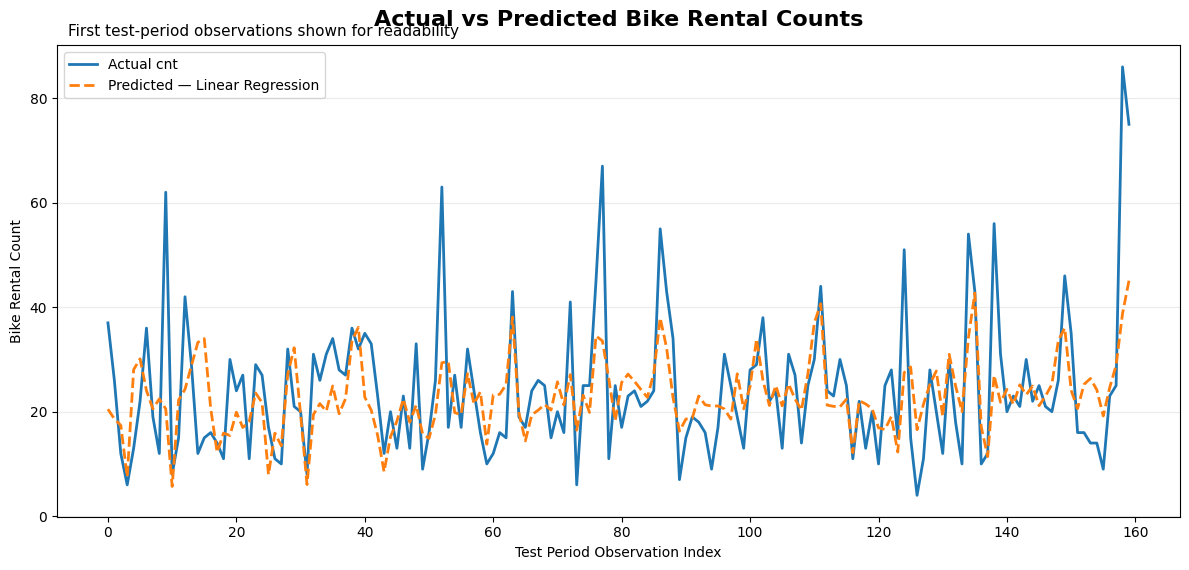

In [21]:
# ============================================================
# CELL 21 — ACTUAL VS PREDICTED CHART FOR BEST MODEL
# ============================================================

# Map model names to their prediction arrays.
prediction_lookup = {
    "Mean Baseline": baseline_pred,
    "Linear Regression": linear_pred,
    "PoissonRegressor": poisson_pred,
    "Negative Binomial GLM": negative_binomial_pred,
}

# Select the best prediction array based on MAE.
best_predictions = prediction_lookup[best_mae_model]

# Limit the chart to the first 160 test points for readability.
n_points = min(160, len(y_test))
plot_index = np.arange(n_points)

# Create the line chart.
fig, ax = plt.subplots(figsize=(12, 5.8))
ax.plot(plot_index, y_test.values[:n_points], linewidth=2.0, label="Actual cnt")
ax.plot(plot_index, best_predictions[:n_points], linewidth=2.0, linestyle="--", label=f"Predicted — {best_mae_model}")

# Add titles and labels.
ax.set_title("Actual vs Predicted Bike Rental Counts", fontsize=16, fontweight="bold", pad=14)
ax.text(0.01, 1.02, "First test-period observations shown for readability", transform=ax.transAxes, fontsize=11)
ax.set_xlabel("Test Period Observation Index")
ax.set_ylabel("Bike Rental Count")
ax.legend(frameon=True)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Output-aware conclusion.
show_conclusion(
    "Actual vs predicted chart created",
    f"The chart compares real demand against <b>{best_mae_model}</b> predictions. Check whether the predicted line follows peaks and dips. This visual adds business context beyond a metric table."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">24. statsmodels GLM Summary Snapshot</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Full statsmodels summaries can be very long. For a print-ready notebook, we show a compact coefficient snapshot for the Negative Binomial model.</p>
    <p><b>Interpretation reminder:</b> GLM coefficients with a log link are on the log-count scale. Positive coefficients increase expected count; negative coefficients decrease expected count.</p>
  </div>
</div>

In [22]:
# ============================================================
# CELL 22 — COMPACT GLM COEFFICIENT SNAPSHOT
# ============================================================

# Create readable names for the statsmodels design matrix.
glm_feature_names = ["const"] + list(processed_feature_names)

# Store Negative Binomial coefficients in a dataframe.
nb_coef_table = pd.DataFrame({
    "feature": glm_feature_names,
    "coefficient": negative_binomial_glm.params,
    "absolute_coefficient": np.abs(negative_binomial_glm.params),
})

# Show strongest non-intercept coefficients.
nb_top_coefficients = (
    nb_coef_table.query("feature != 'const'")
    .sort_values("absolute_coefficient", ascending=False)
    .head(12)
    .drop(columns="absolute_coefficient")
)

# Display coefficient snapshot.
display(nb_top_coefficients.round(4))

# Output-aware conclusion.
top_feature = nb_top_coefficients.iloc[0]["feature"]
top_coef = nb_top_coefficients.iloc[0]["coefficient"]
coef_direction = "increases" if top_coef > 0 else "decreases"
show_conclusion(
    "Coefficient snapshot created",
    f"The strongest coefficient by absolute size is <code>{top_feature}</code>. Its coefficient is <b>{top_coef:,.4f}</b>, which means it <b>{coef_direction}</b> expected rental counts on the log-count scale, holding other processed features constant."
)

,feature,coefficient
33,cat__weekday_5,0.7617
22,cat__hr_18,0.7340
34,cat__weekday_6,0.7243
35,cat__workingday_1,0.6672
21,cat__hr_17,0.6630
37,cat__weathersit_3,-0.5691
12,cat__hr_8,0.5376
11,cat__hr_7,0.4965
20,cat__hr_16,0.2876
15,cat__hr_11,0.2080


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">25. When Is Negative Binomial Better Than Poisson?</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This is the conceptual question in the MVD. Negative Binomial is better when the count target has more variability than Poisson expects. The practical sign is overdispersion: variance much larger than mean.</p>
    <p>This cell writes a data-driven recommendation using the actual overdispersion ratio and model comparison results.</p>
  </div>
</div>

In [23]:
# ============================================================
# CELL 23 — DATA-DRIVEN NEGATIVE BINOMIAL RECOMMENDATION
# ============================================================

# Decide if the data shows overdispersion.
is_overdispersed = overdispersion_ratio > 2

# Compare Poisson and Negative Binomial by MAE.
poisson_vs_nb = pd.DataFrame({
    "Model": ["PoissonRegressor", "Negative Binomial GLM"],
    "MAE": [poisson_mae, nb_mae],
    "Mean Poisson Deviance": [poisson_mpd, nb_mpd]
}).round(3)

display(poisson_vs_nb)

# Create a concise business recommendation.
if is_overdispersed and nb_mae <= poisson_mae:
    nb_recommendation = "Negative Binomial is recommended because the target is overdispersed and it performs at least as well as Poisson by MAE."
elif is_overdispersed and nb_mae > poisson_mae:
    nb_recommendation = "Negative Binomial is theoretically justified by overdispersion, but PoissonRegressor performs better by MAE on this test split. Keep both in the comparison."
elif not is_overdispersed and poisson_mae <= nb_mae:
    nb_recommendation = "Poisson is sufficient here because overdispersion is not strong and it performs at least as well as Negative Binomial by MAE."
else:
    nb_recommendation = "Negative Binomial performs better by MAE, but the overdispersion signal is not strong. Use it only if the business accepts extra model complexity."

# Output-aware conclusion.
show_conclusion(
    "Negative Binomial decision explained",
    f"Overdispersion ratio: <b>{overdispersion_ratio:,.2f}</b>. {nb_recommendation}"
)

,Model,MAE,Mean Poisson Deviance
0,PoissonRegressor,8.279,4.541
1,Negative Binomial GLM,8.198,4.207


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">26. Final Business Recommendation</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The final recommendation should not only say which model has the best metric. It should explain what the model is good for and what risk remains.</p>
    <p>This cell creates a compact print-ready recommendation table.</p>
  </div>
</div>

In [24]:
# ============================================================
# CELL 24 — FINAL BUSINESS RECOMMENDATION TABLE
# ============================================================

# Create a compact recommendation table.
recommendation_table = pd.DataFrame({
    "Question": [
        "Best operational model by MAE",
        "Best count-model fit by Poisson deviance",
        "Count-data warning",
        "Leakage warning",
        "Recommended business use",
    ],
    "Answer": [
        best_mae_model,
        best_mpd_model,
        f"Variance/mean ratio = {overdispersion_ratio:.2f}; {dispersion_message}",
        "Do not use casual or registered to predict cnt because cnt = casual + registered.",
        "Use the selected model to support bike availability planning, demand monitoring and staffing decisions.",
    ]
})

display(recommendation_table)

# Output-aware conclusion.
show_conclusion(
    "Notebook 3 business recommendation complete",
    f"For this run, use <b>{best_mae_model}</b> when the goal is lowest average rental-count error. Keep the overdispersion result in mind when deciding whether Poisson is enough or Negative Binomial is justified."
)

,Question,Answer
0,Best operational model by MAE,Linear Regression
1,Best count-model fit by Poisson deviance,Negative Binomial GLM
2,Count-data warning,Variance/mean ratio = 6.94; The variance is mu...
3,Leakage warning,Do not use casual or registered to predict cnt...
4,Recommended business use,Use the selected model to support bike availab...


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">27. Professional Count-Model Note: Zero Inflation and Exposure</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Two professional count-model topics are useful to mention even if the MVD does not require full implementation.</p>
    <p><b>Zero inflation:</b> if the dataset has too many zero-count periods, a normal Poisson model may underfit. In that case, a Zero-Inflated Poisson or Zero-Inflated Negative Binomial model can be considered.</p>
    <p><b>Exposure / offset:</b> if each row represents a different observation length, we add an offset so the model compares fair count rates. In this notebook, each row represents one comparable time period, so no offset is required.</p>
  </div>
</div>

In [25]:
# ============================================================
# CELL 25 — ZERO-INFLATION AND EXPOSURE CHECK
# ============================================================

# Calculate the share of zero-count rows in the full target.
zero_count_share = (bike_df["cnt"] == 0).mean()
zero_count_rows = int((bike_df["cnt"] == 0).sum())

# Create a compact table for the notebook.
zero_inflation_table = pd.DataFrame({
    "Check": ["Zero-count rows", "Zero-count share", "Offset needed?"],
    "Result": [f"{zero_count_rows:,}", f"{zero_count_share:.2%}", "No — rows represent comparable bike-rental periods"]
})

display(zero_inflation_table)

# Create output-aware interpretation.
if zero_count_share > 0.20:
    zero_message = "The zero-count share is high. A zero-inflated count model may be worth considering in a deeper project."
elif zero_count_share > 0.05:
    zero_message = "There are some zero-count rows, but not enough to make zero inflation the main modeling issue here."
else:
    zero_message = "Zero-count rows are rare, so a standard count model is reasonable for this notebook."

# Output-aware conclusion.
show_conclusion(
    "Zero-inflation and exposure checked",
    f"Zero-count share is <b>{zero_count_share:.2%}</b>. {zero_message} No exposure offset is used because each row represents a comparable rental period."
)

,Check,Result
0,Zero-count rows,0
1,Zero-count share,0.00%
2,Offset needed?,No — rows represent comparable bike-rental per...


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">28. GLM Selection Metrics: AIC, BIC and Pseudo-R²</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>For GLMs, normal R² is not the main model-fit measure. We often inspect <b>AIC</b>, <b>BIC</b>, deviance and <b>pseudo-R²</b>.</p>
    <p><b>Simple meaning:</b> AIC/BIC reward fit but penalize unnecessary complexity. Pseudo-R² compares model deviance against null deviance. Higher pseudo-R² is better, but it is not interpreted exactly like normal Linear Regression R².</p>
  </div>
</div>

In [26]:
# ============================================================
# CELL 26 — GLM SELECTION METRICS TABLE
# ============================================================

# Calculate pseudo-R² values from deviance and null deviance.
poisson_pseudo_r2 = 1 - (poisson_glm.deviance / poisson_glm.null_deviance)
nb_pseudo_r2 = 1 - (negative_binomial_glm.deviance / negative_binomial_glm.null_deviance)

# Build a compact GLM model-selection table.
glm_selection_table = pd.DataFrame({
    "Model": ["Poisson GLM", "Negative Binomial GLM"],
    "AIC": [poisson_glm.aic, negative_binomial_glm.aic],
    "BIC_deviance": [poisson_glm.bic_deviance, negative_binomial_glm.bic_deviance],
    "Training Deviance": [poisson_glm.deviance, negative_binomial_glm.deviance],
    "Pseudo_R2": [poisson_pseudo_r2, nb_pseudo_r2],
    "Test MAE": [poisson_glm_mae, nb_mae],
})

display(glm_selection_table.round(4))

# Identify the best GLM by AIC.
best_glm_by_aic = glm_selection_table.sort_values("AIC").iloc[0]["Model"]

# Output-aware conclusion.
show_conclusion(
    "GLM selection metrics reviewed",
    f"The better GLM by AIC is <b>{best_glm_by_aic}</b>. Pseudo-R² helps compare GLM fit improvement over a null model, but final business choice should still consider test MAE and model simplicity."
)

,Model,AIC,BIC_deviance,Training Deviance,Pseudo_R2,Test MAE
0,Poisson GLM,5977.8699,-1425.4798,2730.9069,0.3238,8.1279
1,Negative Binomial GLM,4907.8004,-3738.1406,418.2461,0.3088,8.1980


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">29. Compact Theory Recap</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <table style="border-collapse:collapse; width:100%; font-size:14px;">
      <tr style="background:#dbeafe;"><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Concept</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Simple Meaning</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Notebook Use</th></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>GLM</b></td><td style="border:1px solid #dbeafe; padding:8px;">Regression family that supports different target distributions.</td><td style="border:1px solid #dbeafe; padding:8px;">Used for Poisson and Negative Binomial count models.</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>Poisson Regression</b></td><td style="border:1px solid #dbeafe; padding:8px;">Model for non-negative counts.</td><td style="border:1px solid #dbeafe; padding:8px;">Predicts bike rental counts using log-link logic.</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>Negative Binomial</b></td><td style="border:1px solid #dbeafe; padding:8px;">Poisson-style model with extra dispersion.</td><td style="border:1px solid #dbeafe; padding:8px;">Used when count variance is much larger than mean.</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>QQ Plot</b></td><td style="border:1px solid #dbeafe; padding:8px;">Checks whether residuals look normal.</td><td style="border:1px solid #dbeafe; padding:8px;">Shows whether Linear Regression assumptions are weak for count data.</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>Mean Poisson Deviance</b></td><td style="border:1px solid #dbeafe; padding:8px;">Count-specific error metric.</td><td style="border:1px solid #dbeafe; padding:8px;">Used to compare count-model quality.</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>AIC/BIC</b></td><td style="border:1px solid #dbeafe; padding:8px;">Model comparison criteria that penalize complexity.</td><td style="border:1px solid #dbeafe; padding:8px;">Used for statsmodels GLM interpretation.</td></tr>
    </table>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">30. Final MVD Coverage Checklist</h2>
  </div>
  <div style="border:1px solid #bbf7d0; background:#f0fdf4; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <table style="border-collapse:collapse; width:100%; font-size:14px;">
      <tr style="background:#dcfce7;"><th style="border:1px solid #bbf7d0; padding:8px; text-align:left;">MVD Requirement</th><th style="border:1px solid #bbf7d0; padding:8px; text-align:left;">Covered?</th><th style="border:1px solid #bbf7d0; padding:8px; text-align:left;">Evidence in Notebook</th></tr>
      <tr><td style="border:1px solid #bbf7d0; padding:8px;">Train standard Linear Regression on Bike Sharing target cnt</td><td style="border:1px solid #bbf7d0; padding:8px;">Yes</td><td style="border:1px solid #bbf7d0; padding:8px;">Sections 8–12</td></tr>
      <tr><td style="border:1px solid #bbf7d0; padding:8px;">Check residuals for normality with QQ plot</td><td style="border:1px solid #bbf7d0; padding:8px;">Yes</td><td style="border:1px solid #bbf7d0; padding:8px;">Sections 13–15</td></tr>
      <tr><td style="border:1px solid #bbf7d0; padding:8px;">Train PoissonRegressor</td><td style="border:1px solid #bbf7d0; padding:8px;">Yes</td><td style="border:1px solid #bbf7d0; padding:8px;">Section 16</td></tr>
      <tr><td style="border:1px solid #bbf7d0; padding:8px;">Compare MAE and Mean Poisson Deviance</td><td style="border:1px solid #bbf7d0; padding:8px;">Yes</td><td style="border:1px solid #bbf7d0; padding:8px;">Sections 17, 21 and 22</td></tr>
      <tr><td style="border:1px solid #bbf7d0; padding:8px;">Implement Negative Binomial Regression with statsmodels</td><td style="border:1px solid #bbf7d0; padding:8px;">Yes</td><td style="border:1px solid #bbf7d0; padding:8px;">Sections 19–20</td></tr>
      <tr><td style="border:1px solid #bbf7d0; padding:8px;">Explain when Negative Binomial is better than Poisson</td><td style="border:1px solid #bbf7d0; padding:8px;">Yes</td><td style="border:1px solid #bbf7d0; padding:8px;">Section 25</td></tr>
      <tr><td style="border:1px solid #bbf7d0; padding:8px;">Additional professional topics</td><td style="border:1px solid #bbf7d0; padding:8px;">Yes</td><td style="border:1px solid #bbf7d0; padding:8px;">Leakage guard, time-aware split, overdispersion, AIC/BIC, coefficient snapshot, business recommendation</td></tr>
    </table>
    <p style="margin-top:14px;"><b>Notebook 3 status:</b> MVD Expert requirements are fully covered and extended with professional count-modeling diagnostics.</p>
  </div>
</div>